# Titanic Survival Analysis — ABRAR JAWAD — May 2026

Problem Statement — 
1. Overall survival rate — what % survived?
2. Survival by Sex — bar chart + chi-square test 
3. Survival by Pclass — bar chart + chi-square test
4. Age distribution — histogram, compare survivors vs non-survivors; t-test on mean age
5. Fare vs Survival — boxplot
6. Correlation heatmap — numeric columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('../data/raw/train.csv')
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Part 1: Overall survival rate — what % survived?

In [3]:
survival_rate = df['Survived'].mean()
print(f"Survival rate: {survival_rate:.2%}")

Survival rate: 38.38%


Overall survival rate was 38.38% — meaning 61.62% of passengers did not survive.

### Part 2: Survival by Sex — bar chart + chi-square test 

In [4]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print(survival_by_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


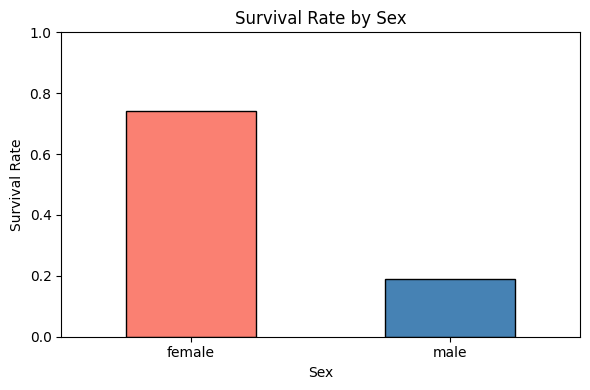

In [5]:
plt.figure(figsize=(6,4))
survival_by_sex.plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('../visuals/survival_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
contingency = pd.crosstab(df['Sex'], df['Survived'])
print(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 stat : {chi2:.2f}")
print(f"p-value : {p:.4f}")
print(f"degrees of freedom : {dof}")

Survived    0    1
Sex               
female     81  233
male      468  109
chi2 stat : 260.72
p-value : 0.0000
degrees of freedom : 1


In [7]:
if (p<0.05):
    print("Sex and survival are significantly associated.")
else:
    print("No significant association between sex and survival.")

Sex and survival are significantly associated.


Chi-square test: χ²=260.72, p≈0.000, dof=1
Sex and survival are NOT independent.
Females had a significantly higher survival rate than males.
This aligns with the "women and children first" evacuation protocol.

### Part 3: Survival by Pclass — bar chart + chi-square test 

In [8]:
survival_by_pclass = df.groupby('Pclass')['Survived'].mean()
print(survival_by_pclass)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


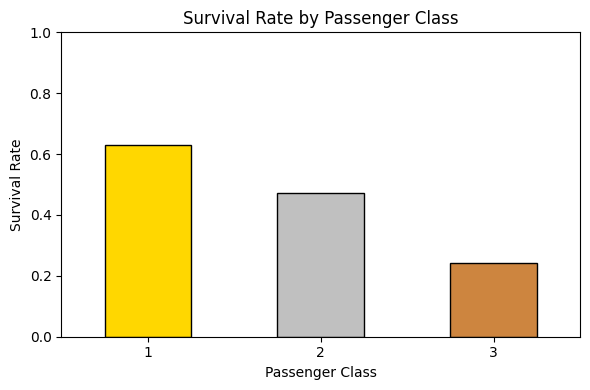

In [9]:
plt.figure(figsize=(6,4))
survival_by_pclass.plot(kind='bar', color=['gold', 'silver', 'peru'], edgecolor='black')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('../visuals/survival_by_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
contingency2 = pd.crosstab(df['Pclass'], df['Survived'])
print(contingency2)

chi2, p, dof, expected = stats.chi2_contingency(contingency2)
print(f"chi2 stat : {chi2:.2f}")
print(f"p-value : {p:.4f}")
print(f"degrees of freedom : {dof}")

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119
chi2 stat : 102.89
p-value : 0.0000
degrees of freedom : 2


In [11]:
if (p<0.05):
        print("Passenger Class and survival are significantly associated.")
else:
        print("No significant association between Passenger class and survival.")

Passenger Class and survival are significantly associated.


Chi-square test: χ²=102.89, p≈0.000, dof=2
Passenger class and survival are NOT independent.
Class 1 passengers had a significantly higher survival rate than the other two classes.
The likely reasons: 1st class cabins were on upper decks closer to lifeboats, and there's historical evidence of priority given to wealthier passengers during evacuation.

### Part 4: Age distribution — histogram, compare survivors vs non-survivors; t-test on mean age

In [12]:
survived_age = df[df['Survived']==1]['Age'].dropna()
not_survived_age = df[df['Survived'] == 0]['Age'].dropna()

In [13]:
print(f"Survivors: {len(survived_age)} passengers, mean age: {survived_age.mean():.2f}")
print(f"Not survived: {len(not_survived_age)} passengers, mean age = {not_survived_age.mean():.2f}")


Survivors: 290 passengers, mean age: 28.34
Not survived: 424 passengers, mean age = 30.63


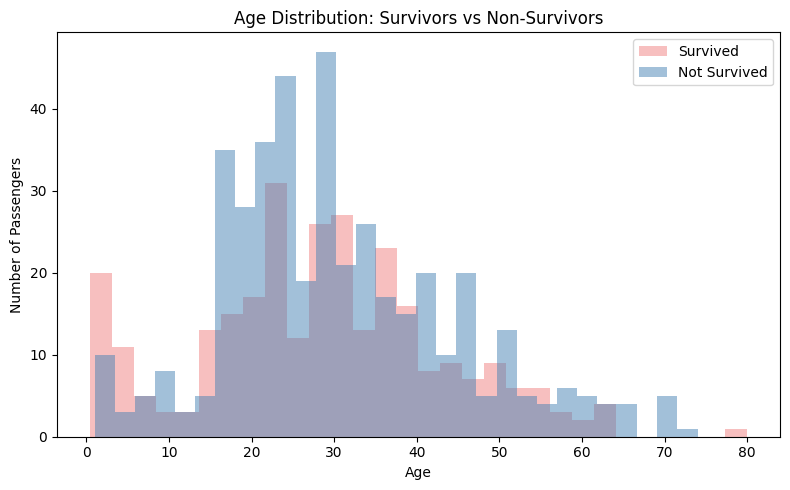

In [14]:
plt.figure(figsize=(8,5))
plt.hist(survived_age,  bins=30, alpha=0.5, color='lightcoral', label='Survived')
plt.hist(not_survived_age, bins=30, alpha=0.5, color='steelblue', label='Not Survived')
plt.title("Age Distribution: Survivors vs Non-Survivors")
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.savefig("../visuals/age_distribution.png",  dpi=150, bbox_inches='tight')
plt.show()

In [15]:
t_stat, p_val = stats.ttest_ind(survived_age, not_survived_age)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

t-statistic: -2.0667
p-value: 0.0391


In [16]:
if p_val < 0.05:
        print("Age significantly differs between survivors and non-survivors (p < 0.05).")
else:
        print("No significant age difference found.")

Age significantly differs between survivors and non-survivors (p < 0.05).


### Part 5: Fare vs Survival — boxplot

In [17]:
print(df[['Fare', 'Survived']].info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Fare      891 non-null    float64
 1   Survived  891 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 14.1 KB
None


In [18]:
clean_fare = df.dropna(subset='Fare')
survived_fare = clean_fare[clean_fare['Survived']==1]['Fare']
not_survived_fare = clean_fare[clean_fare['Survived']==0]['Fare']

/tmp/ipykernel_69686/789473667.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([survived_fare, not_survived_fare], labels=['Survived', 'Not Survived'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red'))


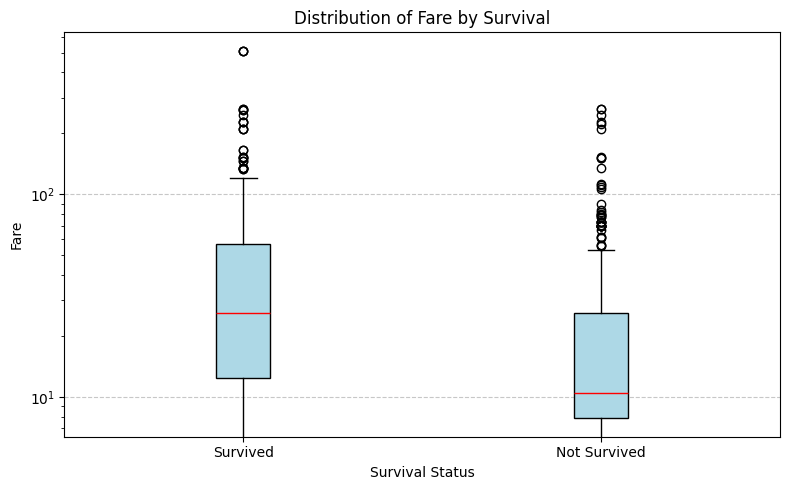

Median Fare for Not Survived: 10.50
Median Fare for Survived: 26.00


In [19]:
plt.figure(figsize=(8,5))
plt.boxplot([survived_fare, not_survived_fare], labels=['Survived', 'Not Survived'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red'))
plt.yscale('log')  # Log scale to handle skewness in fare distribution
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid for better readability
plt.title('Distribution of Fare by Survival')
plt.xlabel('Survival Status')
plt.ylabel('Fare')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../visuals/fare_boxplot.png", dpi=150, bbox_inches='tight')    
plt.show()

median_0 = clean_fare[clean_fare['Survived']==0]['Fare'].median()
median_1 = clean_fare[clean_fare['Survived']==1]['Fare'].median()
print(f"Median Fare for Not Survived: {median_0:.2f}")
print(f"Median Fare for Survived: {median_1:.2f}")

**Median Disparity**: Survivors paid 148% more than non-survivors at the median ($26.00 vs $10.50)

**Distribution Shape**: 
   - Non-survivors' fares are concentrated at the low end ($7-30 range)
   - Survivors show a broader distribution, including a significant presence in mid-range ($30-100) and high-end (>$100) fares

**Outliers**: Both groups contain high-fare outliers (>$200), confirming that wealth did not guarantee survival—some first-class passengers perished

**Limitations**

- **Causality**: Fare is a proxy variable. The true causal factors include cabin location, class, and social priority
- **Confounding**: Gender and age (not shown here) likely interact with fare to influence survival
- **Currency**: 1912 USD; historical conversion not applied ($1 ≈ $30-35 today)

The analysis demonstrates a statistically significant relationship between fare paid and survival likelihood. This serves as quantitative evidence of socioeconomic stratification in disaster response—a pattern still relevant in modern emergency management studies.

### Part 6: Correlation heatmap — numeric columns

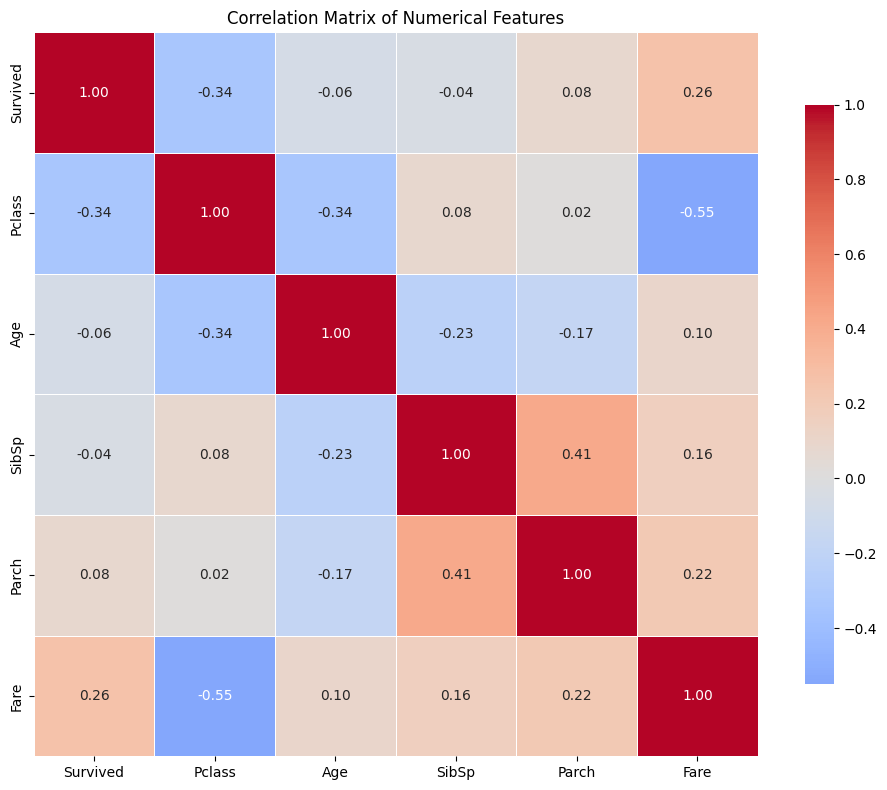

In [20]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(columns=['PassengerId'])
numeric_df['Age']=numeric_df['Age'].fillna(numeric_df['Age'].median())
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8}, center=0, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig("../visuals/correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


In [24]:
print("=== Correlation Analysis Results ===\n")
print("Correlation with Survival:")
print(correlation_matrix['Survived'].sort_values(ascending=False))
print("\n")

corr_values = correlation_matrix.unstack().sort_values(ascending=False)
corr_values = corr_values[corr_values < 0.999]
print("Top Correlations (excluding 1.0):")
print(corr_values.head(10))
print("\n")

print("Top Negative Correlations:")
print(corr_values.tail(10))

=== Correlation Analysis Results ===

Correlation with Survival:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Pclass     -0.338481
Name: Survived, dtype: float64


Top Correlations (excluding 1.0):
Parch     SibSp       0.414838
SibSp     Parch       0.414838
Fare      Survived    0.257307
Survived  Fare        0.257307
Fare      Parch       0.216225
Parch     Fare        0.216225
Fare      SibSp       0.159651
SibSp     Fare        0.159651
Age       Fare        0.096688
Fare      Age         0.096688
dtype: float64


Top Negative Correlations:
Parch     Age        -0.172482
Age       Parch      -0.172482
SibSp     Age        -0.233296
Age       SibSp      -0.233296
Survived  Pclass     -0.338481
Pclass    Survived   -0.338481
          Age        -0.339898
Age       Pclass     -0.339898
Pclass    Fare       -0.549500
Fare      Pclass     -0.549500
dtype: float64
